In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


In [2]:
data_train_path = 'Fruits_Vegetabless/Fruits_Vegetables/train'
data_test_path = 'Fruits_Vegetabless/Fruits_Vegetables/test'
data_val_path = 'Fruits_Vegetabless/Fruits_Vegetables/validation'

In [3]:
img_width = 180
img_height =180 

In [7]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False)

Found 3119 files belonging to 36 classes.


In [9]:
data_cat = data_train.class_names

In [11]:
data_cat

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']

In [13]:
data_val = tf.keras.utils.image_dataset_from_directory(data_val_path,
                                                       image_size=(img_height,img_width),
                                                       batch_size=32,
                                                        shuffle=False,
                                                       validation_split=False)

Found 351 files belonging to 36 classes.


In [15]:
data_test = tf.keras.utils.image_dataset_from_directory(
data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 358 files belonging to 36 classes.


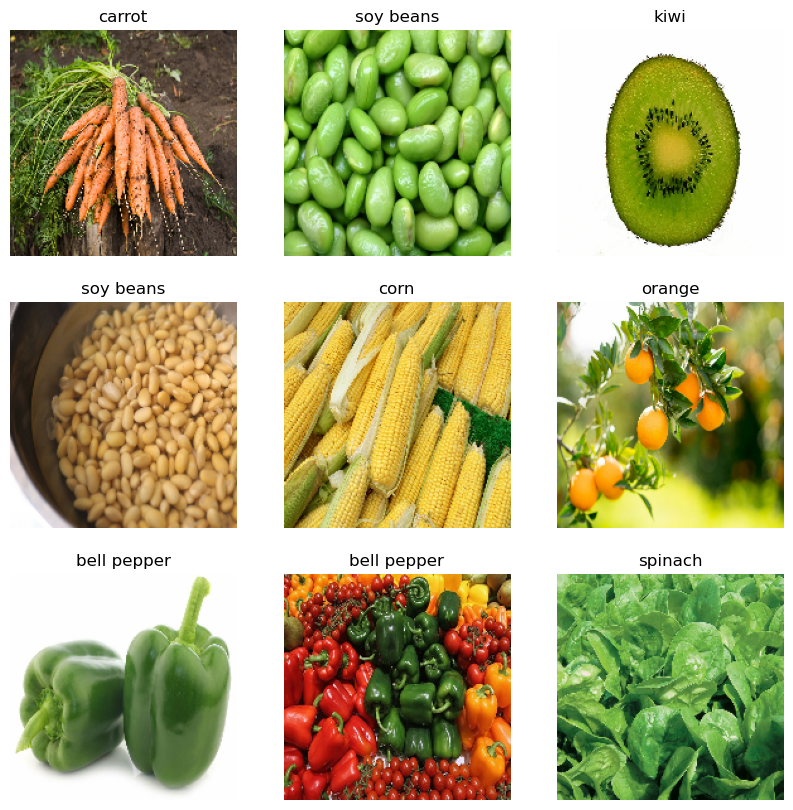

In [17]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [19]:
from tensorflow.keras.models import Sequential

In [21]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [23]:
model = Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.2),
    layers.Dense(128),
    layers.Dense(len(data_cat))
                  
])

In [25]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [27]:
epochs_size = 25
history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 102s 966ms/step - accuracy: 0.0585 - loss: 4.1841 - val_accuracy: 0.2678 - val_loss: 2.7242
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 130s 853ms/step - accuracy: 0.2049 - loss: 2.7741 - val_accuracy: 0.5328 - val_loss: 1.7813
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 142s 844ms/step - accuracy: 0.3761 - loss: 2.1639 - val_accuracy: 0.6866 - val_loss: 1.1663
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 149s 919ms/step - accuracy: 0.5434 - loss: 1.5726 - val_accuracy: 0.8490 - val_loss: 0.6753
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 137s 864ms/step - accuracy: 0.6945 - loss: 1.0627 - val_accuracy: 0.8860 - val_loss: 0.5721
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 84s 851ms/step - accuracy: 0.8037 - loss: 0.6782 - val_accuracy: 0.9060 - val_loss: 0.4676
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 137s 803ms/step - accuracy: 0.8697 - loss: 0.4695 - val_accuracy: 0.9288 - val_loss: 0.4402
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 78s 792ms/step - accuracy: 0.9091 - loss: 0.3255 - va

Text(0.5, 1.0, 'Loss')

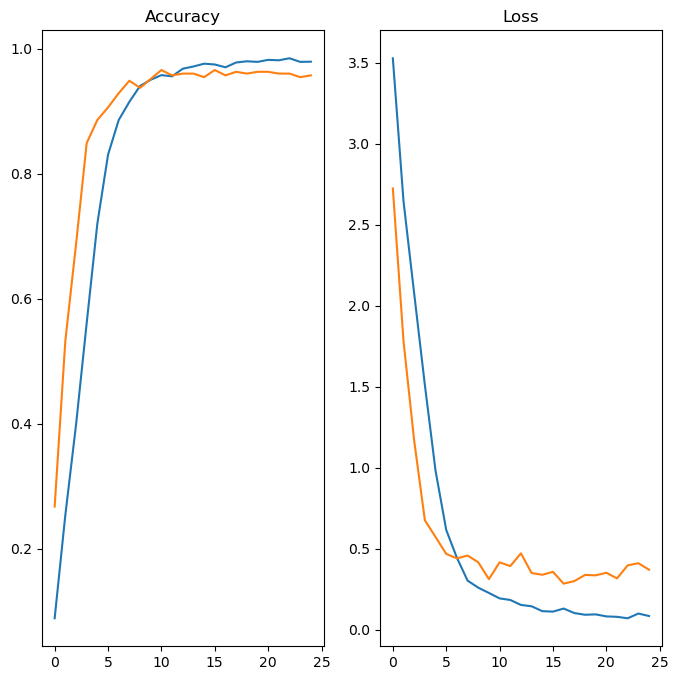

In [29]:
epochs_range = range(epochs_size)
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy')
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss')
plt.title('Loss')

In [31]:
image = 'Apple.jpg'
image = tf.keras.utils.load_img(image, target_size=(img_height,img_width))
img_arr = tf.keras.utils.array_to_img(image)
img_bat=tf.expand_dims(img_arr,0)

In [33]:
predict = model.predict(img_bat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 580ms/step


In [35]:
score = tf.nn.softmax(predict)

In [37]:
print('Veg/Fruit in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)],np.max(score)*100))

Veg/Fruit in image is apple with accuracy of 99.94


In [39]:
model.save('Image_classify.keras')